## Notebook 1: K-Means Clustering

### 1A: Understanding K-Means

#### Importing libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import (StandardScaler, MinMaxScaler)

from sklearn.cluster import KMeans 
from sklearn.mixture import GaussianMixture
from sklearn.datasets import (make_blobs, load_sample_image)
from sklearn.utils import shuffle

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

np.random.seed(24)
# stores the randomely generated data in seed 24

#### Synthetic Example Data Generation

'_make_blobs_' is a utility function specifically designed to synthesise isotropic Gaussian blobs (spherical data clusters) for clustering algorithms.


In [2]:
X, y = make_blobs(
    n_samples = 500,
    # total number of data points
    n_features = 2,
    # total number of features or columns (dimentions) in dataset
    centers = 4,
    # number of distinct clusters to generate
    cluster_std = 1.2,
    # Standard Deviation of the data points around each cluster center
    random_state = 24
)

X.shape

(500, 2)

In [3]:
df_blobs = pd.DataFrame(X, columns = ['Feature_1', 'Feature_2'])

df_blobs.head()

,Feature_1,Feature_2
0,6.958770,5.467134
1,-3.935457,4.069545
2,-0.316688,6.654792
3,8.590125,-2.019886
4,7.596023,4.665674


#### Example Data Plotting

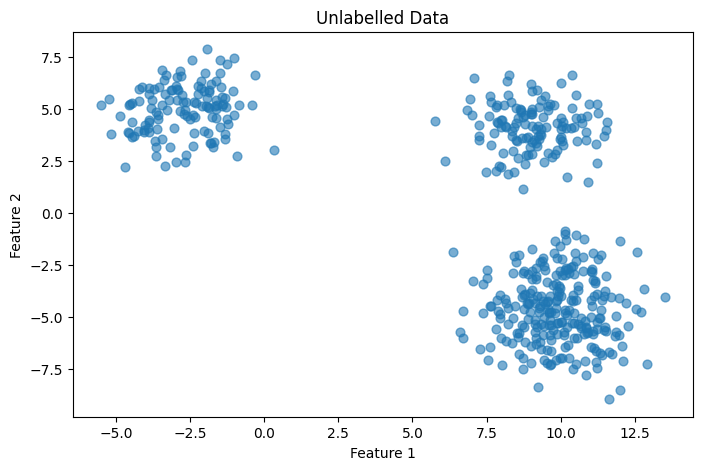

In [4]:
plt.figure(figsize = (8,5))

plt.scatter(X[:,0], X[:,1], alpha = 0.6, s = 40)

plt.title('Unlabelled Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show();

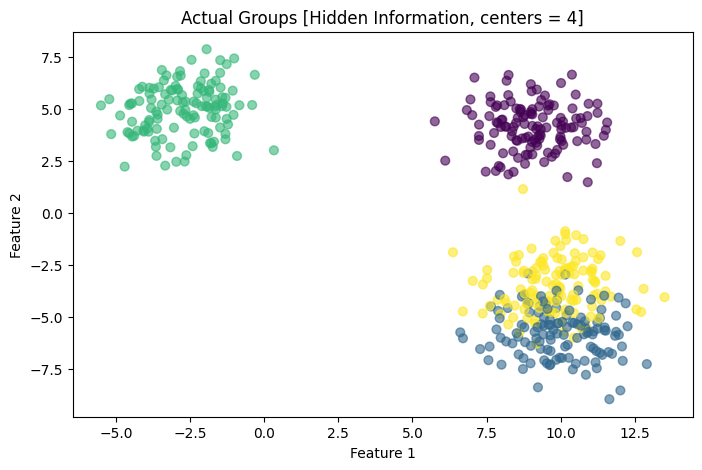

In [5]:
plt.figure(figsize = (8,5))

plt.scatter(X[:,0], X[:,1], alpha = 0.6, s = 40, c = y)

plt.title('Actual Groups [Hidden Information, centers = 4]')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show();

#### Shuffle data

Shuffling ensures that any subset of data is a fair, random representation of the whole dataset.

In [7]:
X1 = shuffle(X, random_state = 24)

X1.shape

(500, 2)

#### Distance

Distance calculates the distance from a data point to all cluster centers (centroids). The point is then assigned to whichever centroid is the closest.

In [8]:
point_1 = np.array([2,3])
point_2 = np.array([5,7])

distance = np.sqrt(sum(point_2 - point_1)**2)

print(distance)

7.0


#### KMeans

KMeans is the constructor function from Scikit-Learn used to build clustering model.

In [9]:
kmeans = KMeans(
    n_clusters = 4,
    # number of groups/distinct clusters required 
    random_state = 24,
    n_init = 10
    # number of initialisations - forces scikit-learn to run the entire KMeans algorithm 10 times to find the best clustering result
)

labels = kmeans.fit_predict(X1)

print(labels[:10])

[0 1 2 0 0 0 0 2 0 3]


#### Plotting Clusters

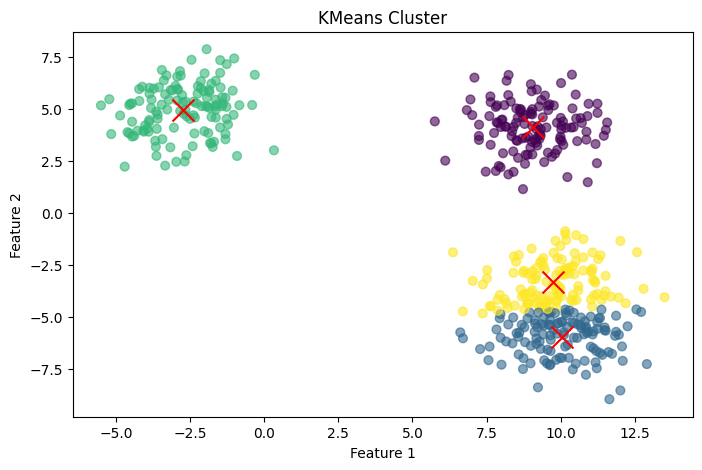

In [10]:
plt.figure(figsize = (8,5))

plt.scatter(X1[:,0], X1[:,1], alpha = 0.6, s = 40, c = labels, marker = 'o')

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker = 'x', color = 'red', s = 250)

plt.title('KMeans Cluster')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show();

#### Scaling Example

In [11]:
scale_demo = pd.DataFrame({
    'age': [22,35,45,55],
    'income': [25000,70000,90000,120000]
})

scale_demo

,age,income
0,22,25000
1,35,70000
2,45,90000
3,55,120000


#### Before Scaling

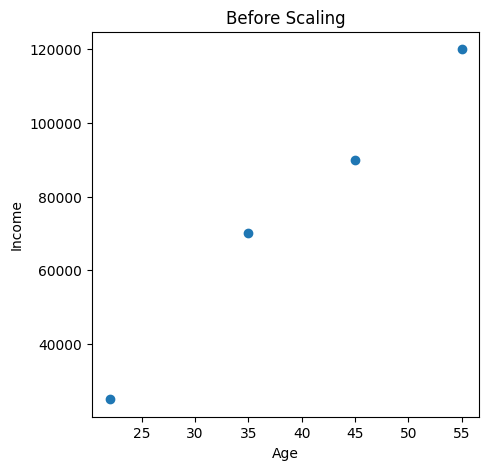

In [12]:
plt.figure(figsize = (5,5))

plt.scatter(scale_demo['age'], scale_demo['income'])

plt.title('Before Scaling')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show();

#### After Scaling

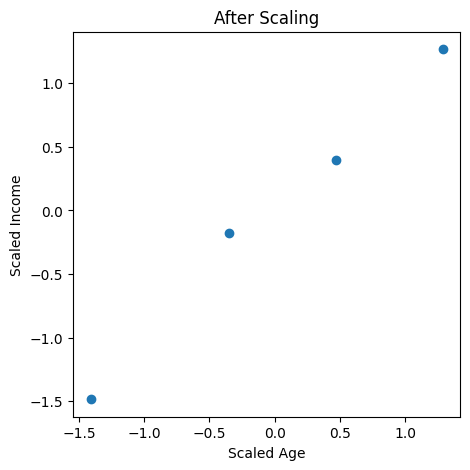

In [19]:
scaled_demo = StandardScaler().fit_transform(scale_demo)

plt.figure(figsize = (5,5))

plt.scatter(scaled_demo[:,0], scaled_demo[:,1])

plt.title('After Scaling')
plt.xlabel('Scaled Age')
plt.ylabel('Scaled Income')
plt.show();

### 1B: Advertising Synthetic Dataset + Feature Insight

In [6]:
# Generating dataset of 8 features and 5000 data points

n = 5000
# number of synthetic data points

# Blobs synthesised via via make_blobs functions
raw_X, labelled_data = make_blobs(
    n_samples = n,
    n_features = 8,
    centers = 4,
    cluster_std = 1.5,
    # introduces natural 'noise' and overlap between groups
    random_state = 24
)

# Normalising to a 0-1 range to handle mapping predictably
scaled_X = MinMaxScaler().fit_transform(raw_X)

df = pd.DataFrame()

# Scaling Formula = Minimum_Value + (Percentage * Total_Range (Max_Val - Min_Val))

# Column 1 - Driven by feature 0
df['ad_budget'] = 1000 + scaled_X[:, 0] * (50000 - 1000)

# Column 2 - Driven by feature 1, and scaled by budget to prevent impossible anamolies
df['impressions'] = ((10000 + scaled_X[:, 1] * (1000000 - 10000)) * (df['ad_budget'] / 50000)).astype(int)

# Column 3 - Driven by feature 2 (Click-through-rate)
df['ctr'] = 0.01 + scaled_X[:, 2] * (0.05 - 0.01)

# Column 4 - Driven by feature 3
# Baseline clicks is impressions * ctr
# Feature 3 introduces an organic click multiplier (scales clicks by up to 20% +- baseline)
click_multiplier = 0.8 + scaled_X[:, 3] * (1.2 - 0.8)
df['clicks'] = (df['impressions'] * df['ctr'] * click_multiplier).astype(int)

# Column 5 - Driven by feature 4
# Baseline cpc is ad_budget / clicks
# Feature 4 introduces smart vs expensive bidding variance (scales cpc by up to 30% +- baseline)
# +1 added to avoid ZeroDivisionError where clicks are zero
bidding_variance = 0.7 + scaled_X[:, 4] * (1.3 - 0.7)
df['cpc'] = (df['ad_budget'] / (df['clicks'] + 1)) * bidding_variance

# Column 6 - Driven by feature 5
df['time_on_site'] = 10 + scaled_X[:, 5] * (600 - 10)

# Column 7 - Driven by feature 6
df['user_engagement_score'] = 0 + scaled_X[:, 6] * (100 - 0)

# Column 8 - Driven by feature 7
df['device_score'] = (1 + scaled_X[:, 7] * (10 - 1)).astype(int)

df.head()

,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score
0,38931.699766,582346,0.040196,24852,1.514721,109.930284,30.446278,7
1,33771.638731,373635,0.028582,11998,3.369712,175.661388,32.410409,6
2,4704.227014,20361,0.017892,341,15.532846,454.217952,28.186966,1
3,39417.315326,635976,0.044160,29147,1.301943,60.987286,26.207460,7
4,39487.870658,601033,0.041437,26301,1.574464,86.270030,24.286618,7


In [7]:
print('DataFrame Structure:')
df.info()

DataFrame Structure:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ad_budget              5000 non-null   float64
 1   impressions            5000 non-null   int64  
 2   ctr                    5000 non-null   float64
 3   clicks                 5000 non-null   int64  
 4   cpc                    5000 non-null   float64
 5   time_on_site           5000 non-null   float64
 6   user_engagement_score  5000 non-null   float64
 7   device_score           5000 non-null   int64  
dtypes: float64(5), int64(3)
memory usage: 312.6 KB


In [35]:
print('Summary Statistics:')
df.describe()

Summary Statistics:


,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,28924.022935,320357.685600,0.032524,12036.598200,5.620529,280.893508,43.093493,4.439800
std,12147.415367,205998.194005,0.009676,9092.191446,7.656043,150.262258,21.559853,2.098489
min,1000.000000,2615.000000,0.010000,45.000000,1.090364,10.000000,0.000000,1.000000
25%,20218.327129,114369.250000,0.023539,2665.000000,1.807244,140.292720,27.380184,3.000000
50%,33349.103462,320737.500000,0.033615,11213.500000,3.033254,275.187379,35.934945,4.000000
75%,38686.607153,495741.000000,0.041524,19631.500000,7.256431,422.041378,57.770751,6.000000
max,50000.000000,834640.000000,0.050000,35633.000000,335.240041,600.000000,100.000000,10.000000


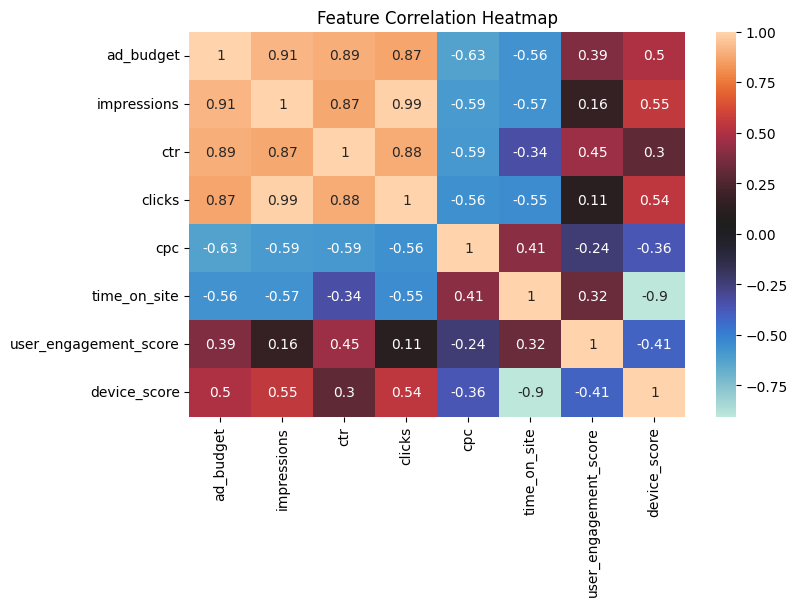

In [38]:
plt.figure(figsize = (8,5))

sns.heatmap(df.corr(), annot = True, cmap = 'icefire')

plt.title('Feature Correlation Heatmap')
plt.show();

### 2. KMeans Pipeline

__K-Means__ is an unsupervised clustering algorithm designed to partition a dataset into distinct, non-overlapping groups (clusters) based on feature similarity.

K - represents a user-defined integer. It is the exact number of distinct clusters (groups) the algorithm is required to find in the dataset.

Means - refers to mathematical average. 

 - For each cluster, the algorithm calculates a central point, which is called the __centroid__.
 - The centroid is the 'mean' position of all the points currently assigned to that specific cluster. If the data has two features (like height and weight), the centroid will be the average height and average weight of all the people in that group.

In [8]:
kmeans_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KMeans(
        n_clusters = 4,
        # number of groups/distinct clusters required 
        random_state = 24,
        n_init = 10
        # number of initialisations - forces scikit-learn to run the entire KMeans algorithm 10 times to find the best clustering result
    ))
])

kmeans_pipe.fit(df)

kmeans_pred = kmeans_pipe.predict(df)

df['clusters'] = kmeans_pred

df.head()

,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score,clusters
0,38931.699766,582346,0.040196,24852,1.514721,109.930284,30.446278,7,3
1,33771.638731,373635,0.028582,11998,3.369712,175.661388,32.410409,6,1
2,4704.227014,20361,0.017892,341,15.532846,454.217952,28.186966,1,2
3,39417.315326,635976,0.044160,29147,1.301943,60.987286,26.207460,7,3
4,39487.870658,601033,0.041437,26301,1.574464,86.270030,24.286618,7,3


In [14]:
print('Cluster Count')
df['clusters'].value_counts(normalize = True)

Cluster Count


clusters
3    0.25
1    0.25
2    0.25
0    0.25
Name: proportion, dtype: float64

In [18]:
cluster_summary = df.groupby('clusters').mean()

print('Cluster Summary')
cluster_summary.round(2)

Cluster Summary


,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score
clusters,,,,,,,,
0,38531.26,423437.56,0.04,15981.48,2.08,381.70,76.93,2.79
1,28567.39,235139.49,0.03,7160.26,4.82,158.49,39.78,5.84
2,9694.34,46680.46,0.02,871.96,13.94,463.38,30.00,2.22
3,38903.11,576173.23,0.04,24132.71,1.65,120.00,25.67,6.91


In [137]:
print('Highest Budget Cluster:', cluster_summary['ad_budget'].idxmax())
print('Highest Engagement Cluster:', cluster_summary['user_engagement_score'].idxmax())
print('Lowest CPC Cluster:', cluster_summary['cpc'].idxmin())

Highest Budget Cluster: 3
Highest Engagement Cluster: 0
Lowest CPC Cluster: 3


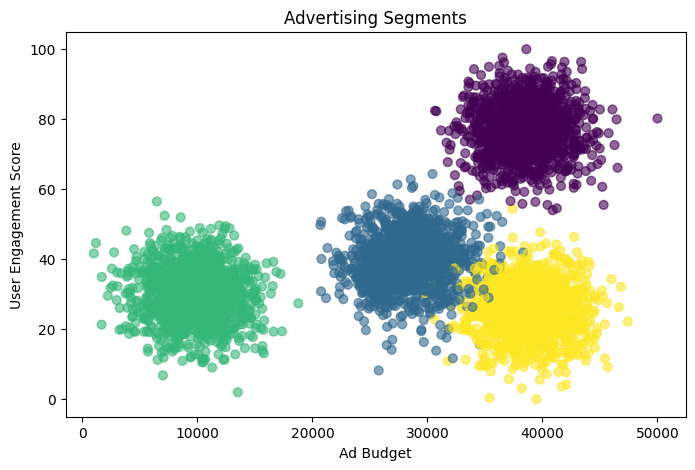

In [64]:
# Plotting Clusters of two features from df

plt.figure(figsize = (8,5))

plt.scatter(df['ad_budget'], df['user_engagement_score'], c = df['clusters'], s = 40, alpha = 0.6)

plt.title('Advertising Segments')
plt.xlabel('Ad Budget')
plt.ylabel('User Engagement Score')
plt.show();

### 3. Inertia

Inertia is a compactness penalty score for clusters. It calculates the straight-line distance from every single data point to the center (centroid) of its assigned cluster, squares those distances, and adds them all together.

Low Inertia = Better Model: The data points are packed tightly around their cluster centers, meaning the groups are dense and highly similar.

High Inertia = Poorer Model: The data points are scattered far away from their cluster centers, meaning the groups are loose, bloated, and poorly separated.

#### KMeans++

By default, Scikit-Learn uses a highly intelligent algorithmic initialisation technique called K-Means++. K-Means++ deliberately spreads out the initial cluster centroids as far apart from each other as possible across data cloud before the training iterations begin.

In [72]:
kmeans_plus_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KMeans(
        n_clusters = 4,
        n_init = 10,
        init = 'k-means++',
        random_state = 24
    ))
])

kmeans_plus_pipe.fit(df.drop(columns = 'clusters'));

#### K-Means Randomisation

By changing this parameter to init = 'random', that smart logic is disabled. This instructs the algorithm to pick K completely random data points from dataframe and declare them as the starting centroids, regardless of how close together or poorly placed they might be.

n_init = 1, further restricts the algorithm to one single attempt only.

In [73]:
kmeans_random_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KMeans(
        n_clusters = 4,
        n_init = 1,
        init = 'random',
        random_state = 24
    ))
])

kmeans_random_pipe.fit(df.drop(columns = 'clusters'));

#### Comparing Inertia

In [79]:
random_model = kmeans_random_pipe.named_steps['model']

plus_model = kmeans_plus_pipe.named_steps['model']

print('Random Init Inertia:', np.round(random_model.inertia_, 2))
print('KMeans++ Inertia:', np.round(plus_model.inertia_, 2))

Random Init Inertia: 13602.3
KMeans++ Inertia: 5615.83


__Key Takeaway__

__KMeans++ Inertia (5,615.83)__: This low score shows that the smart initialisation algorithm successfully found excellent starting positions. The resulting clusters are highly compact, meaning the data points sit very close to their respective centroids. It has successfully captured the true structure of the four marketing campaigns.

__Random Init Inertia (13,602.3)__: This score is more than double the KMeans++ score. It proves that the random model suffered from 'bad luck' during initialisation. It placed its starting centers poorly, got trapped in a sub-optimal layout (a local minimum), and failed to converge on the true groups.

### 4. Distortion

Distortion calculates the average (mean) squared distance from each data point to its closest centroid.

In [88]:
scaled_df = kmeans_pipe.named_steps['scaler'].transform(df.drop(columns = 'clusters'))

km = kmeans_pipe.named_steps['model']

In [95]:
distortion = np.mean(np.min(((scaled_df[:, None] - km.cluster_centers_)**2).sum(axis = 2), axis = 1))

print('Distortion:', np.round(distortion, 3))

Distortion: 1.123


### 5. Elbow Method

The Elbow Method is a visual technique used to find the optimal balance between cluster accuracy and simplicity. As the number of clusters (K) increases, the inertia or distortion score will always drop.

In [111]:
# Droppping the clusters columns df for model training
df_X = df.drop(columns = 'clusters')

inertia = []

k_values = range(1,11)

for k in k_values:
    kmeans_int_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KMeans(
            n_clusters = k,
            n_init = 10,
            random_state = 24
        ))
    ])

    kmeans_int_pipe.fit(df_X)

    inertia.append(kmeans_int_pipe.named_steps['model'].inertia_)

#### Elbow Plot

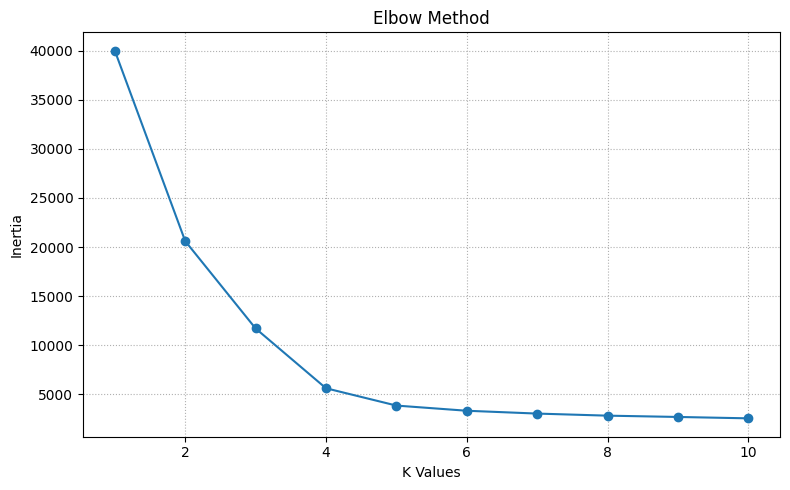

In [110]:
plt.figure(figsize = (8,5))

plt.plot(k_values, inertia, marker = 'o')

plt.title('Elbow Method')
plt.xlabel('K Values')
plt.ylabel('Inertia')

plt.grid(linestyle = ':')
plt.tight_layout()
plt.show();

__Key Takeaway__

Before the Elbow (`K < 4`): Adding more clusters drastically reduces inertia, meaning model is predicting major patterns in the data.

After the Elbow (`K > 4`): Adding more clusters only results in tiny, incremental drops in inertia. This implies that model detects no further genuine patterns in the data and could just be artificially splitting natural groups in half.

### 6. Silhouette Score

The __Silhouette Score__ provides an exact, rock-solid mathematical grade between -1 and +1 to interprete as follow:

- Close to +1: The data point is well-matched to its own cluster and poorly matched to neighboring clusters (indicating excellent clustering).

- Around 0: The data point is near the decision boundary between two overlapping clusters.

- Close to -1: The data point has likely been assigned to the wrong

For every single data point, the Silhouette Score calculates two values:

__Cohesion (a)__: The average distance between that point and all other points in the same cluster (smaller the cohesion, tighter the group).

__Separation (b)__: The average distance between that point and all points in the nearest neighboring cluster (larger the seperation, further apart are the groups).

In [127]:
silhouette_scores = []

for k in range(2, 11):
    kmeans_sil_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KMeans(
            n_clusters = k,
            n_init = 10,
            random_state = 24
        ))
    ])

    kmeans_sil_pred = kmeans_sil_pipe.fit_predict(df_X)

    kmeans_sil_scaled = kmeans_sil_pipe.named_steps['scaler'].transform(df_X)

    sil_score = silhouette_score(kmeans_sil_scaled, kmeans_sil_pred)

    silhouette_scores.append(sil_score)

#pd.DataFrame([silhouette_scores, ], columns = ['Silhouette_Score', 'K_Values']).sort_values(by = 'Silhouette_Score', ascending = False)

pd.DataFrame({
    'Silhouette_Score': silhouette_scores,
    'K_Value': range(2,11)
}).sort_values(by = 'Silhouette_Score', ascending  = False).head(2)

,Silhouette_Score,K_Value
3,0.680483,5
2,0.678393,4


#### Silhouette Plot

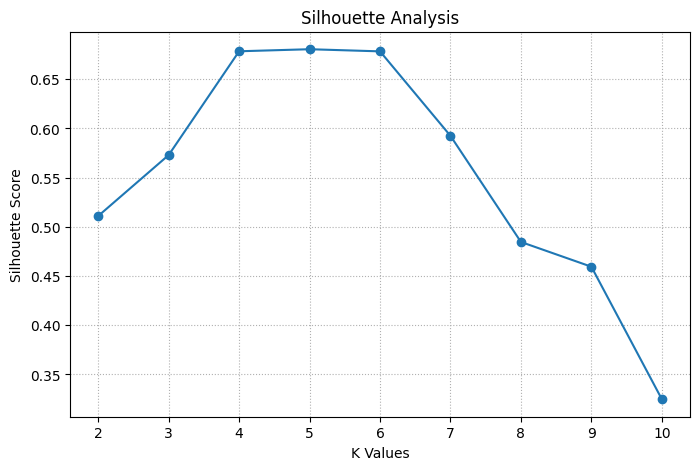

In [115]:
plt.figure(figsize = (8,5))

plt.plot(range(2,11), silhouette_scores, marker = 'o')

plt.title('Silhouette Analysis')
plt.xlabel('K Values')
plt.ylabel('Silhouette Score')
plt.grid(linestyle = ':')
plt.show();

In [130]:
print('Best Silhouette K_Value:', np.argmax(silhouette_scores) + 2)

Best Silhouette K_Value: 5


__Key Takeaway__

Silhouette evaluation shows an exceptionally high score for both K=4 (0.678) and K=5 (0.680). While K=5 achieves a negligible mathematical advantage of 0.002 due to the algorithm splitting the high-variance 'Viral' campaign tail into two sub-segments, **K=4** is purposefully selected as optimal cluster size. 

Choosing K=4 aligns accurately with the Elbow Plot too.

### 7. Image Compression

#### Loading Image

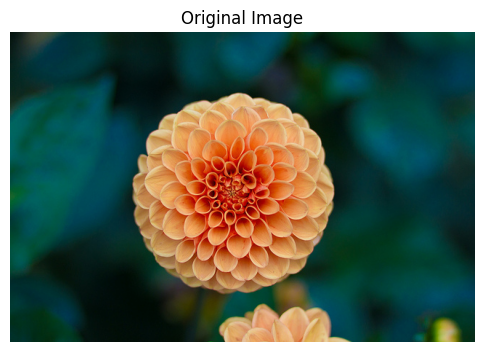

In [152]:
# plt.imshow(load_sample_image('strawberry_image.jpg'))

image = load_sample_image('flower.jpg')

plt.figure(figsize = (6,6))

plt.imshow(image)

plt.title('Original Image')
plt.axis('off')
plt.show();

#### Preparing Pixel

In [188]:
print('Image Original 3D Shape (Height, Width, RGB Channel):', image.shape, '\n')

pixels = image.reshape(-1, 3)
# -1 is a special NumPy shortcut that automatically multiply the total height by the total width, 
# and squashes all pixels into a single, massive vertical column

print('Image Compressed 2D Shape (Total Number of Pixels, RGB Channel):', pixels.shape)

Image Original 3D Shape (Height, Width, RGB Channel): (427, 640, 3) 

Image Compressed 2D Shape (Total Number of Pixels, RGB Channel): (273280, 3)


In [161]:
pixels

array([[ 2, 19, 13],
       [ 3, 18, 13],
       [ 7, 20, 13],
       ...,
       [ 7, 46, 28],
       [ 8, 45, 28],
       [ 9, 43, 27]], shape=(273280, 3), dtype=uint8)

#### Image Compression (K = 2)

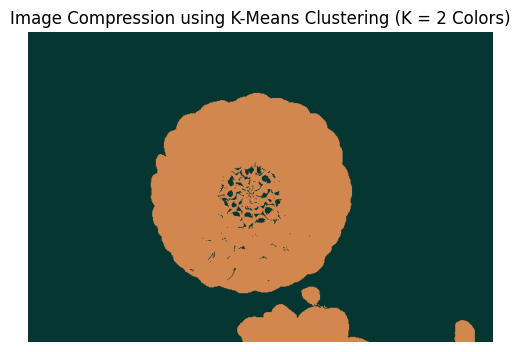

In [187]:
pixels_norm = pixels / 255.0
# Scaling raw pixels to a strict 0.0 - 1.0 range
# 255 represents the maximum possible value for an 8-bit digital color channel.

kmeans_k2 = KMeans(
        n_clusters = 2,
        n_init = 10,
        random_state = 24
)

pixels_k2_pred = kmeans_k2.fit_predict(pixels_norm)

pixels_k2_comp = kmeans_k2.cluster_centers_[pixels_k2_pred]
# this line performs a process called vector quantisation
# kmeans_k2_pipe.cluster_centers_ holds the exact RGB coordinates of 2 final cluster centres
# By passing [pixels_k2_pred] as an index, Python loops through all millions of pixels in image,
# and replace its original color with the exact RGB coordinates of its closest cluster center.

pixels_k2_compressed = np.clip(pixels_k2_comp.reshape(image.shape), 0.0, 1.0)
# this line takes those newly compressed pixels and bends them back into the image's original 3D grid shape (Height, Width, 3 Channels). 
# By reading image.shape, it perfectly restores the original rows and columns so that plotting library knows where each pixel belongs spatially.
# np.clip forces any tiny decimal overflow to stay perfectly inside [0, 1].


plt.figure(figsize = (6,6))

plt.imshow(pixels_k2_compressed)
# .astype(np.uint8) is a vital data-type safety feature. 

plt.title('Image Compression using K-Means Clustering (K = 2 Colors)')
plt.axis('off')
plt.show();

#### Image Compression (K = 4, 8, 16, 32)

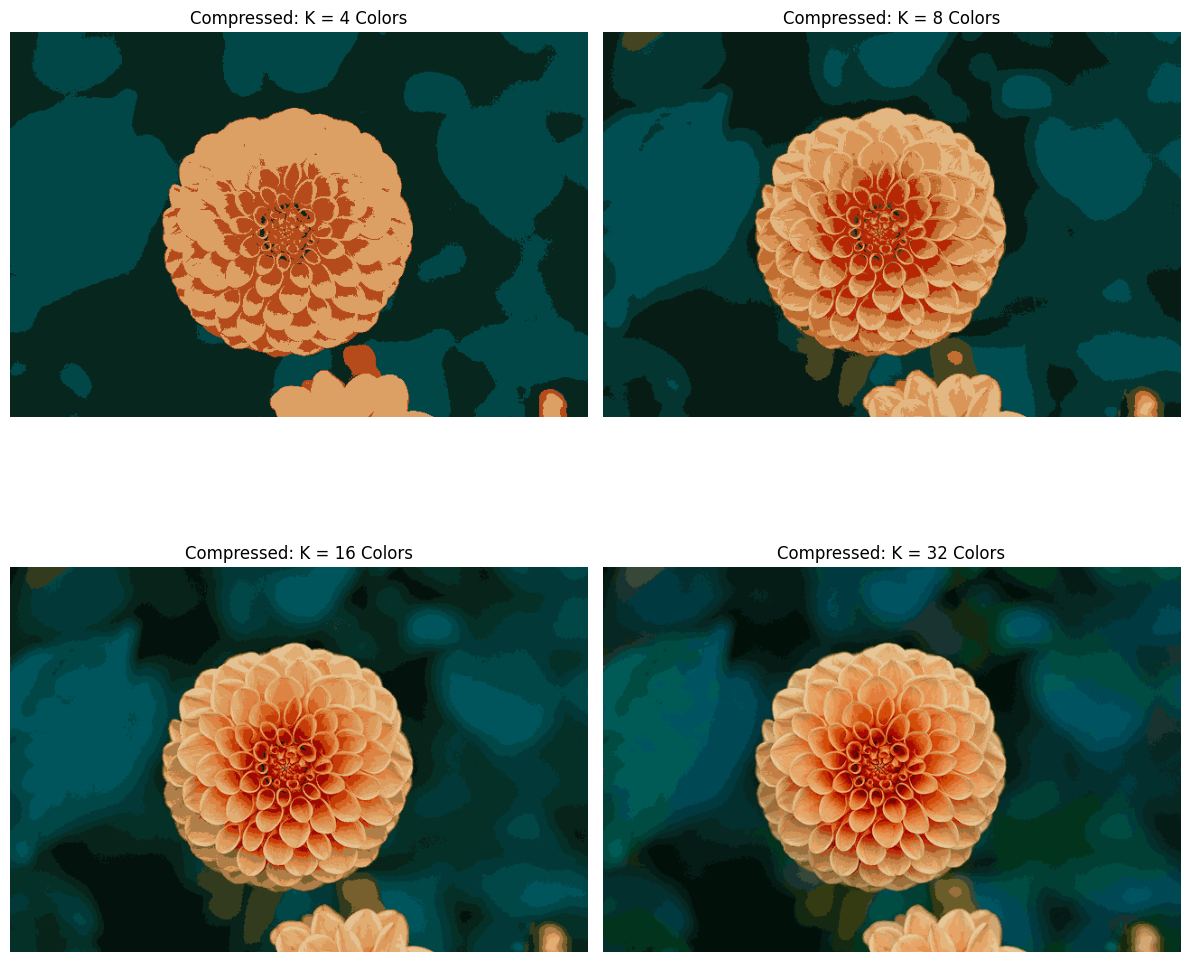

In [186]:
# Scaling raw pixels to a strict 0.0 - 1.0 range
pixels_norm = pixels / 255.0

# Set up a 2x2 grid for plotting our 4 distinct experiments
fig, axes = plt.subplots(2,2, figsize = (12,12))

# .ravel() flattens 2D axes grid into a simple 1D list
axes_flat = axes.ravel()

# Looping through K values and plotting boxes simultaneously

for idx, k in enumerate([4,8,16,32]):

    kmeans_kiter = KMeans(
        n_clusters = k,
        n_init = 5,
        random_state = 24
    )

    kmeans_kiter_pred = kmeans_kiter.fit_predict(pixels_norm)

    kmeans_kiter_comp = kmeans_kiter.cluster_centers_[kmeans_kiter_pred]

    kmeans_kiter_compressed = np.clip(kmeans_kiter_comp.reshape(image.shape), 0.0, 1.0)

    ax = axes_flat[idx]

    ax.imshow(kmeans_kiter_compressed)
    ax.set_title(f'Compressed: K = {k} Colors')
    ax.axis('off')

plt.tight_layout()
plt.show();

### 8. Gaussian Mixture Model

A __Gaussian Mixture Model__ is a probabilistic clustering algorithm. It assumes that all the data points in dataset are generated from a mixture of a finite number of Gaussian (normal bell-curve) distributions with unknown parameters.

In [215]:
gm_model = GaussianMixture(
    n_components = 4,
    random_state = 24
)

gmm_labels = gm_model.fit_predict(X)
# X taken from the synthetic data example blob

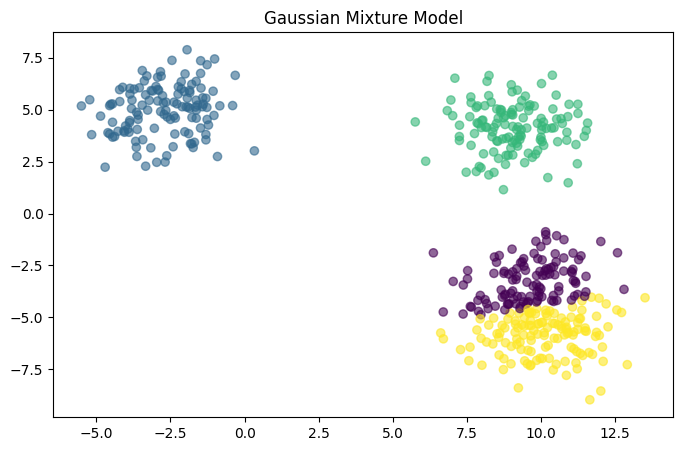

In [244]:
plt.figure(figsize = (8,5))

plt.scatter(X[:, 0], X[:, 1], c = gmm_labels, alpha = 0.6)

plt.title('Gaussian Mixture Model')
plt.show();

#### Soft Clustering

In [217]:
probabilities = gm_model.predict_proba(X)

print('Probabilities First 10 rows:\n', probabilities[:10], '\n')
print('Highest Probability:\n', probabilities.max(axis = 1)[:10])

Probabilities First 10 rows:
 [[7.60931908e-16 1.43996213e-14 1.00000000e+00 1.43730882e-22]
 [3.48013096e-47 1.00000000e+00 4.95600346e-27 7.21632687e-41]
 [4.49769707e-40 1.00000000e+00 2.29484210e-14 4.43401459e-39]
 [9.89904365e-01 2.94748711e-32 1.71990024e-06 1.00939147e-02]
 [3.78070948e-13 1.32217469e-17 1.00000000e+00 9.19353969e-20]
 [2.38122693e-06 5.39680915e-21 9.99997619e-01 2.57104472e-11]
 [7.19420660e-11 5.13243492e-17 1.00000000e+00 1.56490856e-16]
 [9.57823229e-04 1.30315344e-63 2.80314807e-24 9.99042177e-01]
 [3.89058680e-48 1.00000000e+00 7.74574101e-19 1.85357478e-45]
 [9.90425831e-53 1.00000000e+00 2.63944913e-22 1.75687564e-48]] 

Highest Probability:
 [1.         1.         1.         0.98990437 1.         0.99999762
 1.         0.99904218 1.         1.        ]


#### Hard Clustering

In [218]:
km_model = KMeans(
    n_clusters = 4,
    n_init = 10,
    random_state = 24
)

km_labels = km_model.fit_predict(X)

#### Hard Vs Soft Plotting

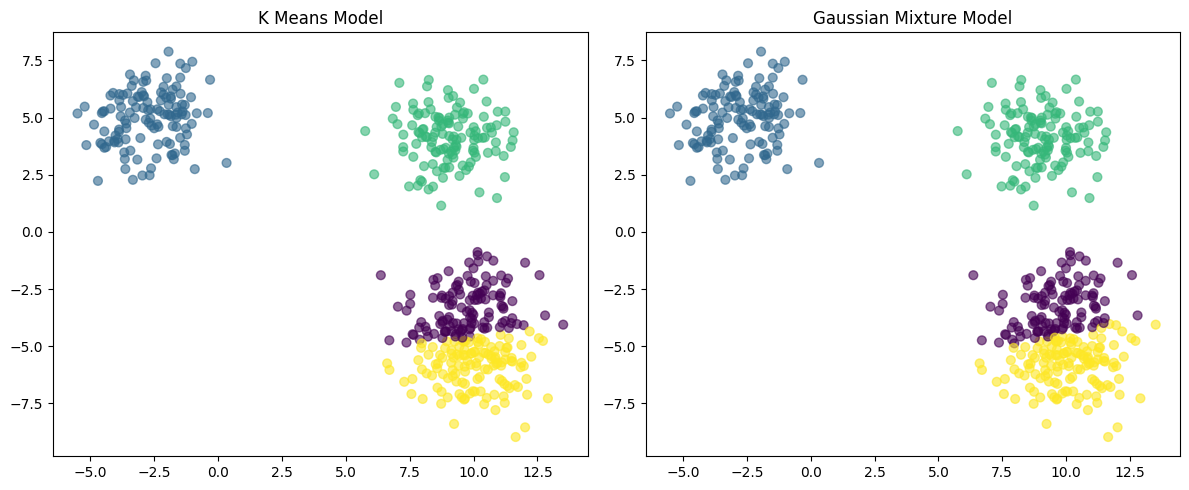

In [229]:
fig, axes = plt.subplots(1, 2, figsize = (12,5))

axes[0].scatter(X[:, 0], X[:, 1], c = km_labels, alpha = 0.6, s = 40)

axes[0].set_title('K Means Model')

axes[1].scatter(X[:, 0], X[:, 1], c = gmm_labels, alpha = 0.6, s = 40)

axes[1].set_title('Gaussian Mixture Model')

plt.tight_layout()
plt.show();

In [232]:
gmm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GaussianMixture(
        n_components = 4,
        random_state = 24
    ))
])

gmm_pred = gmm_pipe.fit_predict(df_X)

df['gmm_clusters'] = gmm_pred

In [246]:
print('Cluster Count:')
df['gmm_clusters'].value_counts(normalize = True)

Cluster Count:


gmm_clusters
3    0.25
1    0.25
2    0.25
0    0.25
Name: proportion, dtype: float64

In [252]:
gmmcluster_summary = df.drop(columns = 'clusters').groupby('gmm_clusters').mean()

print('Cluster Summary')
gmmcluster_summary.round(4)

Cluster Summary


,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score
gmm_clusters,,,,,,,,
0,38531.2601,423437.5608,0.0424,15981.4760,2.0765,381.7006,76.9343,2.7912
1,28567.3860,235139.4888,0.0273,7160.2552,4.8185,158.4900,39.7775,5.8400
2,9694.3365,46680.4584,0.0199,871.9560,13.9363,463.3823,29.9952,2.2216
3,38903.1092,576173.2344,0.0405,24132.7056,1.6509,120.0011,25.6669,6.9064


In [245]:
print('Clusters Comparision Matrix: K-Means Vs. GMM')
pd.crosstab(df['clusters'], df['gmm_clusters'])

Clusters Comparision Matrix: K-Means Vs. GMM


gmm_clusters,0,1,2,3
clusters,,,,
0,1250,0,0,0
1,0,1250,0,0
2,0,0,1250,0
3,0,0,0,1250


__Key Takeaway__

The resulting matrix reveals a flawless, 100% alignment between both algorithms, with exactly 1,250 campaigns matching on the diagonal for all four segments. In unsupervised learning, such an identical convergence between a distance-based partitioner (K-Means) and a density-based probabilistic model (GMM) indicates an exceptionally strong, distinct cluster topology. 

Because the underlying data points are highly cohesive around their respective benchmarks, the geometric centroids calculated by K-Means perfectly mirror the Gaussian distribution means resolved by GMM's Expectation-Maximisation cycles. This absolute agreement confirms marketing profiles are highly stable, mathematically robust, and completely free of ambiguous boundary anomalies.


### 9. Operational Conclusions

In [256]:
# Creating a mapping dictionary to replace abstract integers with business labels
cluster_labels = {
    0: 'Premium Brand',
    1: 'Standard Growth',
    2: 'Low-Cost Mobile',
    3: 'Viral Video'
}

# Mapping the labels to a new descriptive column
df['campaign_persona'] = df['clusters'].map(cluster_labels)

df.to_csv('segmented_marketing_campaigns.csv', index=False)

df.head()

,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score,clusters,gmm_clusters,campaign_persona
0,38931.699766,582346,0.040196,24852,1.514721,109.930284,30.446278,7,3,3,Viral Video
1,33771.638731,373635,0.028582,11998,3.369712,175.661388,32.410409,6,1,1,Standard Growth
2,4704.227014,20361,0.017892,341,15.532846,454.217952,28.186966,1,2,2,Low-Cost Mobile
3,39417.315326,635976,0.044160,29147,1.301943,60.987286,26.207460,7,3,3,Viral Video
4,39487.870658,601033,0.041437,26301,1.574464,86.270030,24.286618,7,3,3,Viral Video
